# 1.3 Gaussian city

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# City-testing section (no real figures saved)

2025-06-27 09:55:06,316 - INFO - Initializing city
2025-06-27 09:55:06,317 - INFO - Calculating density profile for 1 core(s)
2025-06-27 09:55:06,321 - INFO - Running simulation for 5000 steps
2025-06-27 09:55:07,383 - INFO - Simulation completed in 1.06 seconds
2025-06-27 09:55:07,384 - INFO - In-simulation time passed: 7 days
2025-06-27 09:55:07,384 - INFO - Overall, statistics gathered over: 3 days
2025-06-27 09:55:07,384 - INFO - Cumulative rentals happened: 5350
2025-06-27 09:55:07,385 - INFO - Average rentals per car per day: 4.16
2025-06-27 09:55:07,386 - INFO - Average rental time per trip, min: 17.63
2025-06-27 09:55:07,387 - INFO - Average CM1 gain per trip, Eur: 4.41
2025-06-27 09:55:07,387 - INFO - Overall CM2 profit per day, Eur: -837.72


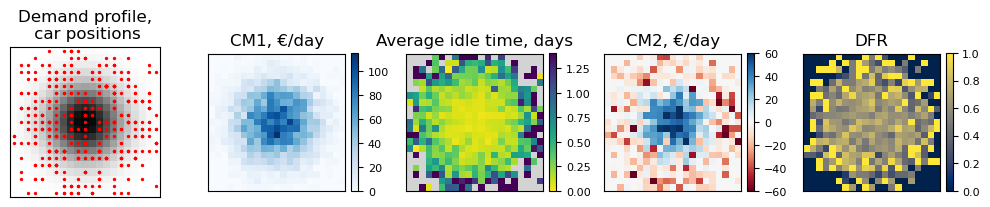

In [1]:
# Testing grounds, not a real figure
config = {
    "seed": 1,  # Random seed
    "city_width": 21, # km 
    "initial_r": 5, # km
    "grid_step": 1, # km. Use 1 for ~intermediate resolution
    "density_sigma": 5, # Gaussian sigma. A bit smaller than default, to have close-to-zero demands
    "n_cars": 500,
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
    "p_factor": 0.06,  # The simplest way to regulate trips/car/day and city profitability
    "tick_in_minutes": 2,
}

import numpy as np
import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
city.init_cars()
city.simulate(5000)
plt.figure(figsize=(10, 5))
city.visualize()

# Introduction to Gaussian City

2025-07-01 10:38:09,748 - INFO - Initializing city
2025-07-01 10:38:09,754 - INFO - Calculating density profile for 1 core(s)


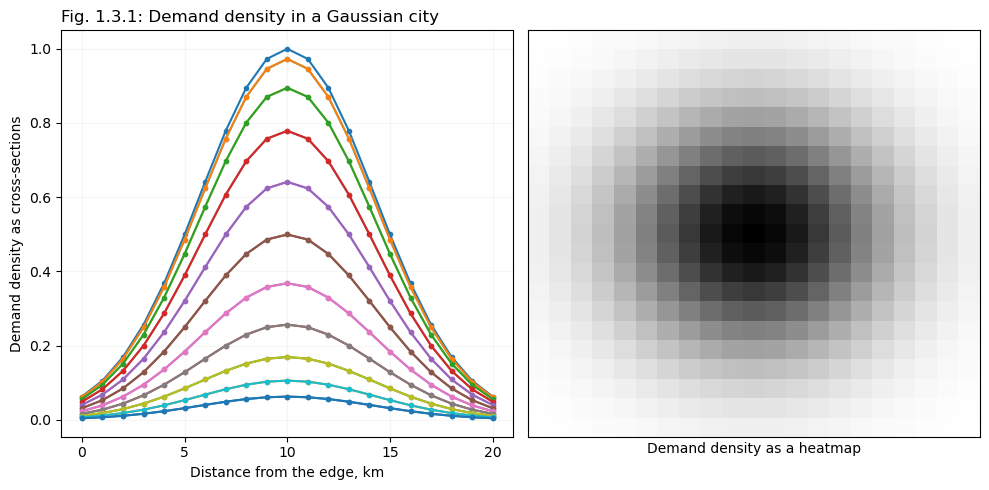

In [88]:
# Population density
config = {
    "seed": 1,  # Random seed
    "city_width": 21, # km 
    "grid_step": 1, 
    "density_sigma": 6, # Gaussian sigma,
}

city = City(config)

# Visualize the city
plt.figure(figsize=(10, 5))

plt.subplot(121);
plt.plot(np.arange(city.grid_size)*config["grid_step"], city.demand, '.-');
plt.grid(alpha=0.1)
plt.xticks([0, 5, 10, 15, 20])
plt.xlabel('Distance from the edge, km')
plt.ylabel('Demand density as cross-sections')

plt.title("Fig. 1.3.1: Demand density in a Gaussian city", loc='left')

plt.subplot(122)
plt.imshow(city.demand.T, aspect='auto', interpolation='none',
          extent=[0, city.grid_size, 0, city.grid_size], cmap='gray_r', vmin=0, vmax=1);
plt.xlabel('Demand density as a heatmap')
plt.xticks([], [])
plt.yticks([], [])

plt.tight_layout()
plt.savefig("../figures/01simple_03city_01population.svg", dpi=300)

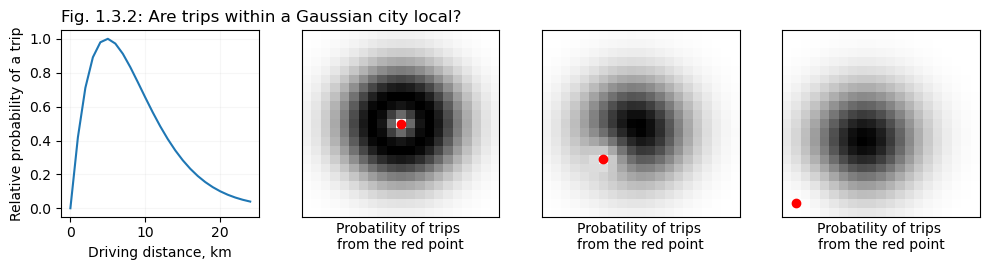

In [9]:
# Spatial mobility curve

n_grid = city.grid_size
density = city.demand

def trip_probability(distance):
    y = distance*np.exp(-(distance**1.2)/8) / 2.11
    return y

x = np.arange(0, 25)
curve = trip_probability(x)

def generate_local_map(i0, j0):
    local_trips = np.zeros(shape=(n_grid, n_grid))
    for i in range(n_grid):
        for j in range(n_grid):
            distance = np.sqrt((i-i0)**2 + (j-j0)**2)*config["grid_step"]        
            local_trips[i, j] = trip_probability(distance)
    local_trips *= density
    local_trips /= local_trips.flatten().max()
    return local_trips

# Figure
plt.figure(figsize=(10, 2.8))
plt.subplot(141)
plt.plot(x, curve)
plt.grid(alpha=0.1)
plt.xlabel('Driving distance, km')
plt.ylabel('Relative probability of a trip')
plt.title("Fig. 1.3.2: Are trips within a Gaussian city local?", loc='left');

plt.subplot(142)
plt.imshow(generate_local_map(10, 10).T, aspect='auto', interpolation='none',
          extent=[0, n_grid, 0, n_grid], cmap='gray_r', vmin=0, vmax=1, origin='lower');
plt.plot(10+0.5, 10+0.5, 'ro')
plt.tight_layout()
plt.xticks([], [])
plt.yticks([], [])
plt.xlabel("Probatility of trips \nfrom the red point")

plt.subplot(143)
plt.imshow(generate_local_map(6, 6).T, aspect='auto', interpolation='none',
          extent=[0, n_grid, 0, n_grid], cmap='gray_r', vmin=0, vmax=1, origin='lower');
plt.plot(6+0.5, 6+0.5, 'ro')
plt.tight_layout()
plt.xticks([], [])
plt.yticks([], [])
plt.xlabel("Probatility of trips \nfrom the red point")

plt.subplot(144)
plt.imshow(generate_local_map(1, 1).T, aspect='auto', interpolation='none',
          extent=[0, n_grid, 0, n_grid], cmap='gray_r', vmin=0, vmax=1, origin='lower');
plt.plot(1+0.5, 1+0.5, 'ro')
plt.tight_layout()
plt.xticks([], [])
plt.yticks([], [])
plt.xlabel("Probatility of trips \nfrom the red point")

plt.savefig("../figures/01simple_03city_02mobility.svg", dpi=300)

# Eventual distribution of cars

2025-06-27 10:08:59,694 - INFO - Initializing city
2025-06-27 10:08:59,697 - INFO - Calculating density profile for 1 core(s)
2025-06-27 10:08:59,812 - INFO - Running simulation for 20 steps
2025-06-27 10:08:59,850 - INFO - Simulation completed in 0.04 seconds
2025-06-27 10:08:59,857 - INFO - In-simulation time passed: 0 days
2025-06-27 10:08:59,861 - INFO - Overall, statistics gathered over: 0 days
2025-06-27 10:08:59,865 - INFO - Cumulative rentals happened: 82
2025-06-27 10:08:59,868 - INFO - Average rentals per car per day: 1.18
2025-06-27 10:08:59,870 - INFO - Average rental time per trip, min: 17.80
2025-06-27 10:08:59,873 - INFO - Average CM1 gain per trip, Eur: 4.45
2025-06-27 10:08:59,875 - INFO - Overall CM2 profit per day, Eur: -7384.93
2025-06-27 10:08:59,967 - INFO - Running simulation for 3000 steps
2025-06-27 10:09:07,600 - INFO - Simulation completed in 7.63 seconds
2025-06-27 10:09:07,601 - INFO - In-simulation time passed: 21 days
2025-06-27 10:09:07,602 - INFO - Over

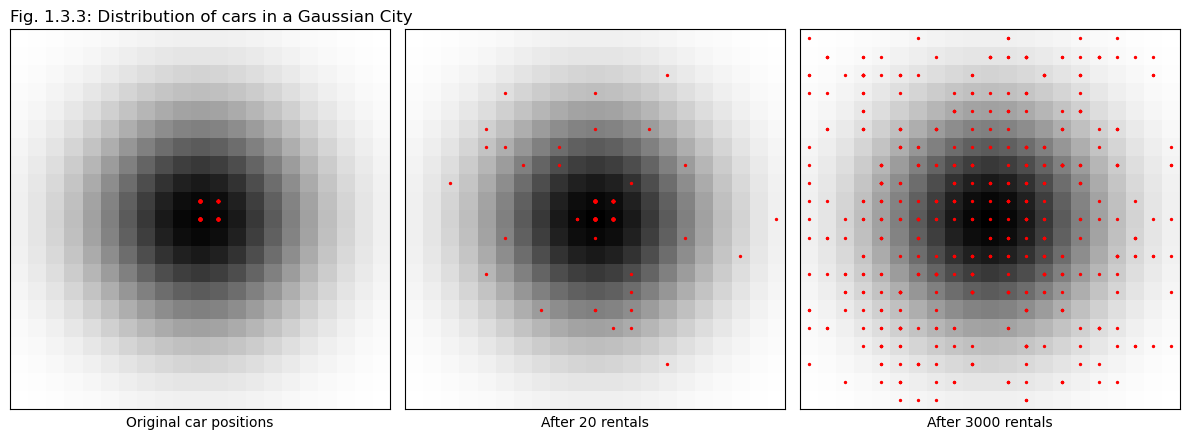

In [6]:
# Evolution of car distribution
config = {
    "seed": 2,  # Random seed
    "city_width": 21, # km 
    "grid_step": 1,     
    "n_cars": 500, 
    "initial_r": 1,
    "density_sigma": 6,
    "p_factor":0.5,
}

import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
city.init_cars()
plt.figure(figsize=(12, 5))
plt.subplot(131)
city.visualize("cars")
plt.xlabel("Original car positions")
plt.title("Fig. 1.3.3: Distribution of cars in a Gaussian City", loc='left');
city.simulate(20)
plt.subplot(132)
city.visualize("cars")
plt.xlabel("After 20 rentals")
city.simulate(3000)
plt.subplot(133)
city.visualize("cars")
plt.xlabel("After 3000 rentals");
plt.savefig("../figures/01simple_03city_03cardistribution.svg", dpi=300)

# Typical stats - base state (no relocations, no price shenanigans, one core)

2025-07-01 10:30:52,606 - INFO - Initializing city
2025-07-01 10:30:52,609 - INFO - Calculating density profile for 1 core(s)
2025-07-01 10:30:52,628 - INFO - Running simulation for 30000 steps
2025-07-01 10:30:56,436 - INFO - ..Simulating step 5000 of 30000
2025-07-01 10:31:01,533 - INFO - ..Simulating step 10000 of 30000
2025-07-01 10:31:06,460 - INFO - ..Simulating step 15000 of 30000
2025-07-01 10:31:11,092 - INFO - ..Simulating step 20000 of 30000
2025-07-01 10:31:16,050 - INFO - ..Simulating step 25000 of 30000
2025-07-01 10:31:20,827 - INFO - Simulation completed in 28.20 seconds
2025-07-01 10:31:20,829 - INFO - In-simulation time passed: 42 days
2025-07-01 10:31:20,831 - INFO - Overall, statistics gathered over: 37 days
2025-07-01 10:31:20,832 - INFO - Cumulative rentals happened: 76780
2025-07-01 10:31:20,833 - INFO - Average rentals per car per day: 4.12
2025-07-01 10:31:20,834 - INFO - Average rental time per trip, min: 17.70
2025-07-01 10:31:20,835 - INFO - Average CM1 gain

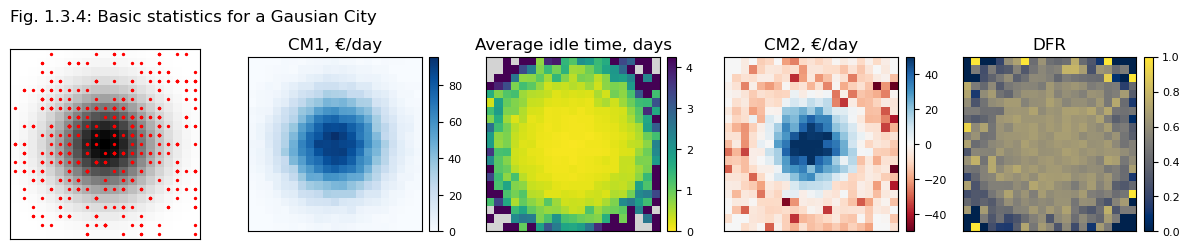

In [71]:
# Nice Gaussian city
config = {
    "seed": 1,  # Random seed
    "city_width": 21, # km 
    "initial_r": 5, # km
    "grid_step": 1, # km. Use 1 for ~intermediate resolution
    "density_sigma": 5, # Gaussian sigma. A bit smaller than default, to have close-to-zero demands
    "n_cars": 500,
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
    "p_factor": 0.06,  # The simplest way to regulate trips/car/day and city profitability
    "tick_in_minutes": 2,
}

import numpy as np
import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
city.init_cars()
city.simulate(30000)
plt.figure(figsize=(12, 3))
city.visualize()
f = plt.gcf()
ax = f.axes[0]
ax.set_title("")  # Clear the title
for text in ax.texts:
    text.remove()
ax.set_title("", pad=0)  # Clear the title 
ax.set_title("Fig. 1.3.4: Basic statistics for a Gausian City", loc='left', pad=20)
plt.tight_layout();
plt.savefig("../figures/01simple_03city_04stats_maps.svg", dpi=300)

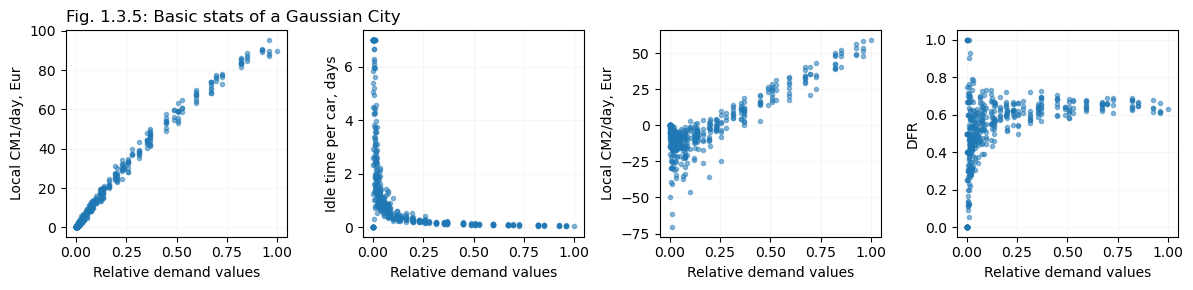

In [72]:
# Stats, use data from the previous run 👆

demand = city.demand.flatten()
cm1 = city.stats_cm1.flatten() / city.n_days
cm2 = city.stats_cm2.flatten() / city.n_days
idle_times = city.stats_idle_time.flatten() * city.tick_in_minutes / 60 / 24 / np.maximum(1, city.stats_n_rentals.flatten())
dfr = city.stats_n_rentals.flatten() / np.maximum(1, city.stats_n_appops.flatten())

plt.figure(figsize=(12, 3))
plt.subplot(141)
plt.title("Fig. 1.3.5: Basic stats of a Gaussian City", loc='left');
plt.plot(demand, cm1, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("Local CM1/day, Eur")

plt.subplot(142)
plt.plot(demand, np.minimum(7, idle_times), '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("Idle time per car, days")

plt.subplot(143)
plt.plot(demand, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("Local CM2/day, Eur")

plt.subplot(144)
plt.plot(demand, dfr, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("DFR")

plt.tight_layout();
plt.savefig("../figures/01simple_03city_05stats_plots.svg", dpi=300)

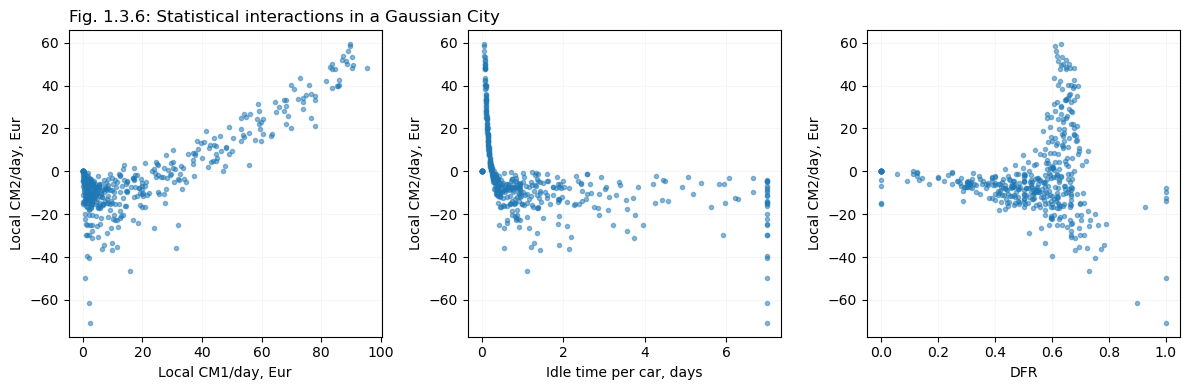

In [73]:
# Fancier stats (from the same run)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.title("Fig. 1.3.6: Statistical interactions in a Gaussian City", loc='left');
plt.plot(cm1, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.ylabel("Local CM2/day, Eur")
plt.xlabel("Local CM1/day, Eur")

plt.subplot(132)
plt.plot(np.minimum(idle_times, 7), cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Idle time per car, days")
plt.ylabel("Local CM2/day, Eur")

plt.subplot(133)
plt.plot(dfr, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("DFR")
plt.ylabel("Local CM2/day, Eur")

plt.tight_layout();
plt.savefig("../figures/01simple_03city_06stats2_plots.svg", dpi=300)

# A flatter city

2025-07-01 11:52:01,337 - INFO - Initializing city
2025-07-01 11:52:01,351 - INFO - Calculating density profile for 1 core(s)


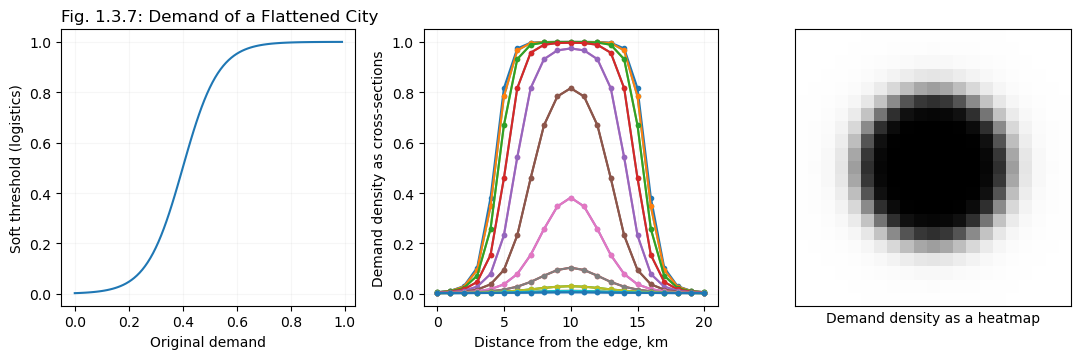

In [91]:
# First check that we like the demand landscape
config = {
    "seed": 2,  # Random seed
    "city_width": 21, # km 
    "grid_step": 1,     
    "n_cars": 400, 
    "initial_r": 3,
    "density_sigma": 6,
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
    "p_factor":0.5,
}

import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
threshold = 0.4
f = lambda x: 1/(1+np.exp(15*(threshold-x)))
city.demand = f(city.demand)

# Visualize the city
plt.figure(figsize=(11, 3.7))
plt.subplot(131)
plt.plot(x, f(x), '-')
plt.grid(alpha=0.1)
plt.xlabel("Original demand")
plt.ylabel("Soft threshold (logistics)")
plt.title("Fig. 1.3.7: Demand of a Flattened City", loc='left')

plt.subplot(133)
plt.imshow(city.demand.T, aspect='auto', interpolation='none',
          extent=[0, city.grid_size, 0, city.grid_size], cmap='gray_r', vmin=0, vmax=1);
plt.xlabel('Demand density as a heatmap')
plt.gca().set_aspect('equal', adjustable='box')
plt.xticks([], [])
plt.yticks([], [])

plt.subplot(132);
plt.plot(np.arange(city.grid_size)*config["grid_step"], city.demand, '.-');
plt.grid(alpha=0.1)
plt.xticks([0, 5, 10, 15, 20])
plt.xlabel('Distance from the edge, km')
plt.ylabel('Demand density as cross-sections')

plt.tight_layout()
plt.savefig("../figures/01simple_03city_07flat_demand.svg", dpi=300)

2025-07-01 10:43:27,539 - INFO - Initializing city
2025-07-01 10:43:27,540 - INFO - Calculating density profile for 1 core(s)
2025-07-01 10:43:27,552 - INFO - Running simulation for 30000 steps
2025-07-01 10:43:32,421 - INFO - ..Simulating step 5000 of 30000
2025-07-01 10:43:37,732 - INFO - ..Simulating step 10000 of 30000
2025-07-01 10:43:42,736 - INFO - ..Simulating step 15000 of 30000
2025-07-01 10:43:47,253 - INFO - ..Simulating step 20000 of 30000
2025-07-01 10:43:52,538 - INFO - ..Simulating step 25000 of 30000
2025-07-01 10:43:57,721 - INFO - Simulation completed in 30.17 seconds
2025-07-01 10:43:57,723 - INFO - In-simulation time passed: 208 days
2025-07-01 10:43:57,724 - INFO - Overall, statistics gathered over: 187 days
2025-07-01 10:43:57,725 - INFO - Cumulative rentals happened: 138009
2025-07-01 10:43:57,727 - INFO - Average rentals per car per day: 1.84
2025-07-01 10:43:57,728 - INFO - Average rental time per trip, min: 20.25
2025-07-01 10:43:57,728 - INFO - Average CM1 g

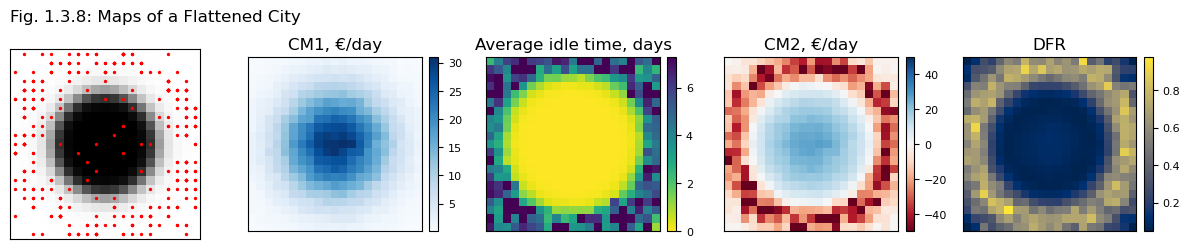

In [90]:
# A flatter city
config = {
    "seed": 2,  # Random seed
    "city_width": 21, # km 
    "grid_step": 1,     
    "n_cars": 400, 
    "initial_r": 3, # A bit wider, to facilitate distribution
    "density_sigma": 6,
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
    "p_factor":0.5,
}

city = City(config)
threshold = 0.4
f = lambda x: 1/(1+np.exp(15*(threshold-x)))
city.demand = f(city.demand)

city.init_cars()
city.simulate(30000)
plt.figure(figsize=(12, 3))
city.visualize()
f = plt.gcf()
ax = f.axes[0]
ax.set_title("")  # Clear the title
for text in ax.texts:
    text.remove()
ax.set_title("", pad=0)  # Clear the title 
ax.set_title("Fig. 1.3.8: Maps of a Flattened City", loc='left', pad=20)
plt.tight_layout();
plt.savefig("../figures/01simple_03city_08flat_maps.svg", dpi=300)

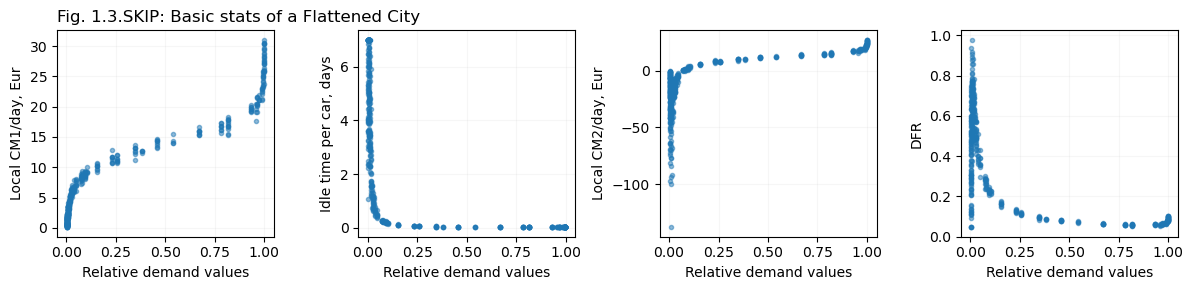

In [81]:
# Stats, use data from the previous run 👆

demand = city.demand.flatten()
cm1 = city.stats_cm1.flatten() / city.n_days
cm2 = city.stats_cm2.flatten() / city.n_days
idle_times = city.stats_idle_time.flatten() * city.tick_in_minutes / 60 / 24 / np.maximum(1, city.stats_n_rentals.flatten())
dfr = city.stats_n_rentals.flatten() / np.maximum(1, city.stats_n_appops.flatten())

plt.figure(figsize=(12, 3))
plt.subplot(141)
plt.title("Fig. 1.3.SKIP: Basic stats of a Flattened City", loc='left');
plt.plot(demand, cm1, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("Local CM1/day, Eur")

plt.subplot(142)
plt.plot(demand, np.minimum(7, idle_times), '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("Idle time per car, days")

plt.subplot(143)
plt.plot(demand, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("Local CM2/day, Eur")

plt.subplot(144)
plt.plot(demand, dfr, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("DFR")

plt.tight_layout()

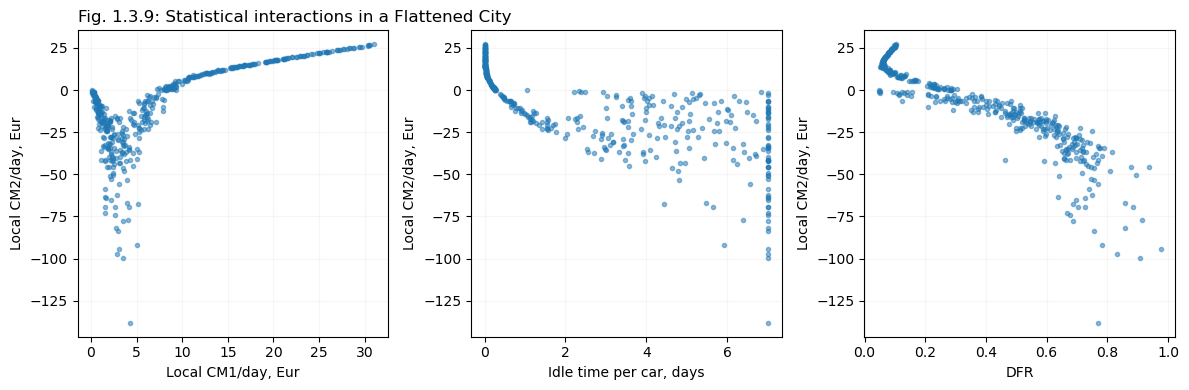

In [82]:
# Fancier stats (from the same run)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.title("Fig. 1.3.9: Statistical interactions in a Flattened City", loc='left');
plt.plot(cm1, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.ylabel("Local CM2/day, Eur")
plt.xlabel("Local CM1/day, Eur")

plt.subplot(132)
plt.plot(np.minimum(idle_times, 7), cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Idle time per car, days")
plt.ylabel("Local CM2/day, Eur")

plt.subplot(133)
plt.plot(dfr, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("DFR")
plt.ylabel("Local CM2/day, Eur")

plt.tight_layout();
plt.savefig("../figures/01simple_03city_09flat_stats.svg", dpi=300)